## ABC Analysis


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   


df = pd.read_csv("inventory_data.csv")
df.head()

,Item_ID,Annual_Demand,Unit_Cost,Annual_Consumption
0,ITEM_001,910,328.56,298989.60
1,ITEM_002,3822,730.96,2793729.12
2,ITEM_003,3142,639.37,2008900.54
3,ITEM_004,516,887.78,458094.48
4,ITEM_005,4476,474.85,2125428.60


In [20]:
df = df.sort_values(by = "Annual_Consumption", ascending=False).reset_index(drop=True)
# df.head()
df["Cumulative_Consumption"] = (df["Annual_Consumption"].cumsum()).round(2)

total_consumption = df["Annual_Consumption"].sum()
#print(f"Total Annual Consumption: {total_consumption}")
df["Cumulative_Percentage"] = ((df["Cumulative_Consumption"] / total_consumption) * 100).round(2)
#df.tail()  
def abc_classifier(row):
    if row['Cumulative_Percentage'] <= 80:
        return "A"
    elif row['Cumulative_Percentage'] <= 95:
        return "B"
    else:
        return "C"
    
df["Category"] = df.apply(abc_classifier, axis=1)
df.head()

,Item_ID,Annual_Demand,Unit_Cost,Annual_Consumption,Cumulative_Consumption,Cumulative_Percentage,Category
0,ITEM_070,4601,985.72,4535297.72,4535297.72,3.73,A
1,ITEM_098,4648,925.07,4299725.36,8835023.08,7.27,A
2,ITEM_056,3993,962.64,3843821.52,12678844.60,10.43,A
3,ITEM_036,3940,808.40,3185096.00,15863940.60,13.05,A
4,ITEM_077,4937,634.14,3130749.18,18994689.78,15.63,A


In [3]:
df.to_csv("abc_results.csv", index=False)
print("ABC classification completed and results saved to abc_results.csv")


ABC classification completed and results saved to abc_results.csv


In [4]:
df.head()

,Item_ID,Annual_Demand,Unit_Cost,Annual_Consumption,Cumulative_Consumption,Cumulative_Percentage,Category
0,ITEM_070,4601,985.72,4535297.72,4535297.72,3.73,A
1,ITEM_098,4648,925.07,4299725.36,8835023.08,7.27,A
2,ITEM_056,3993,962.64,3843821.52,12678844.60,10.43,A
3,ITEM_036,3940,808.40,3185096.00,15863940.60,13.05,A
4,ITEM_077,4937,634.14,3130749.18,18994689.78,15.63,A


Text(0, 0.5, 'Cummulative Percentage (%)')

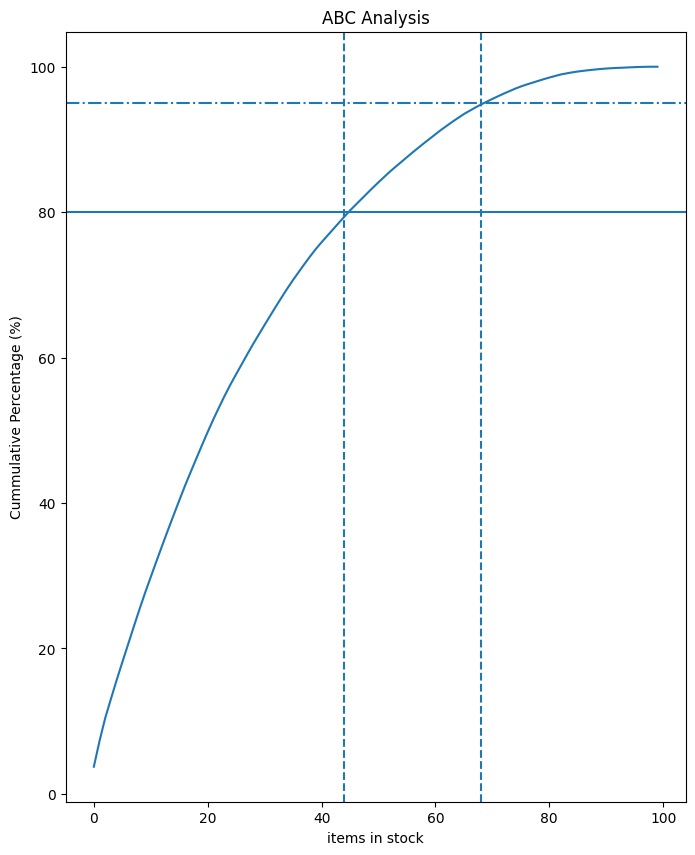

In [5]:
a_end = df[df["Category"] == 'A'].index.max()
b_end = df[df["Category"] == 'B'].index.max()

plt.figure(figsize = (8,10))

plt.plot(df.index, df["Cumulative_Percentage"])

plt.axhline(80, linestyle = '-')
plt.axhline(95, linestyle = '-.')

plt.axvline(a_end, linestyle = '--')
plt.axvline(b_end, linestyle = '--')

plt.title('ABC Analysis')
plt.xlabel('items in stock')
plt.ylabel('Cummulative Percentage (%)')

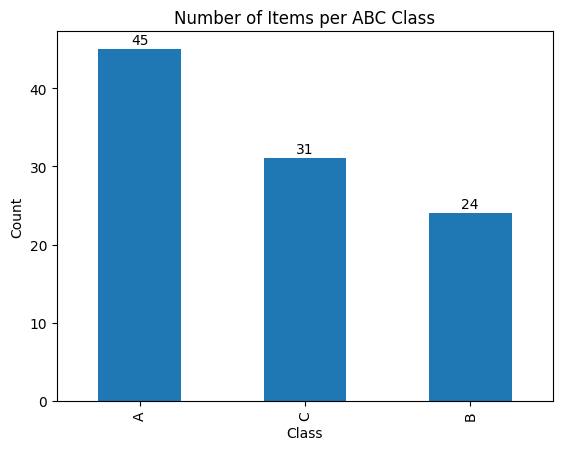

In [6]:
ax = df["Category"].value_counts(normalize=False).plot(
    kind = "bar")

for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),(p.get_x() + p.get_width() /2,
                                 p.get_height() + 0.3 ),
                                 va = 'bottom',
                                 ha = 'center'

    )


plt.title("Number of Items per ABC Class")
plt.xlabel('Class')
plt.ylabel('Count')
plt.yticks(None)
plt.show()

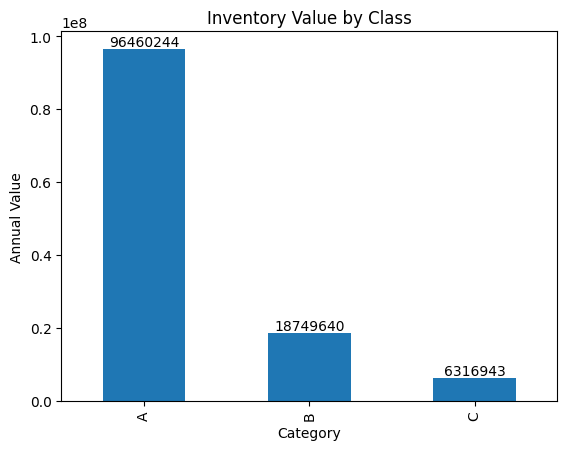

In [7]:
ax = df.groupby("Category")["Annual_Consumption"].sum().plot(kind="bar")
for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),(p.get_x() + p.get_width() /2,
                                 p.get_height() + 0.3 ),
                                 va = 'bottom',
                                 ha = 'center'

    )



plt.title("Inventory Value by Class")
plt.ylabel("Annual Value")
plt.show()

In [18]:
summary = df.groupby('Category')['Annual_Consumption'].sum().reset_index()

# summary.head()

total_sum = summary['Annual_Consumption'].sum()
summary['Percentage_of_Total'] = ((summary['Annual_Consumption'] /total_sum) *100 ).round(2)
summary['Percentage_of_Total'] = summary['Percentage_of_Total'].astype(str) + "%"
summary

,Category,Annual_Consumption,Percentage_of_Total
0,A,96460244.07,79.37%
1,B,18749640.98,15.43%
2,C,6316943.60,5.2%
